In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from rdkit import Chem
import umap

/home/Baaa/miniconda3/envs/cheminf/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_ki = pd.read_csv('data/data.csv')
df_zinc = pd.read_csv('data/data_zinc.csv')

## Histograms

In [3]:
sns.set_theme(style="whitegrid")
descriptors = ['MW', 'LogP', 'HBD', 'HBA']

df_active = df_ki[df_ki['active'] == 1]
df_inactive = df_ki[df_ki['active'] == 0]

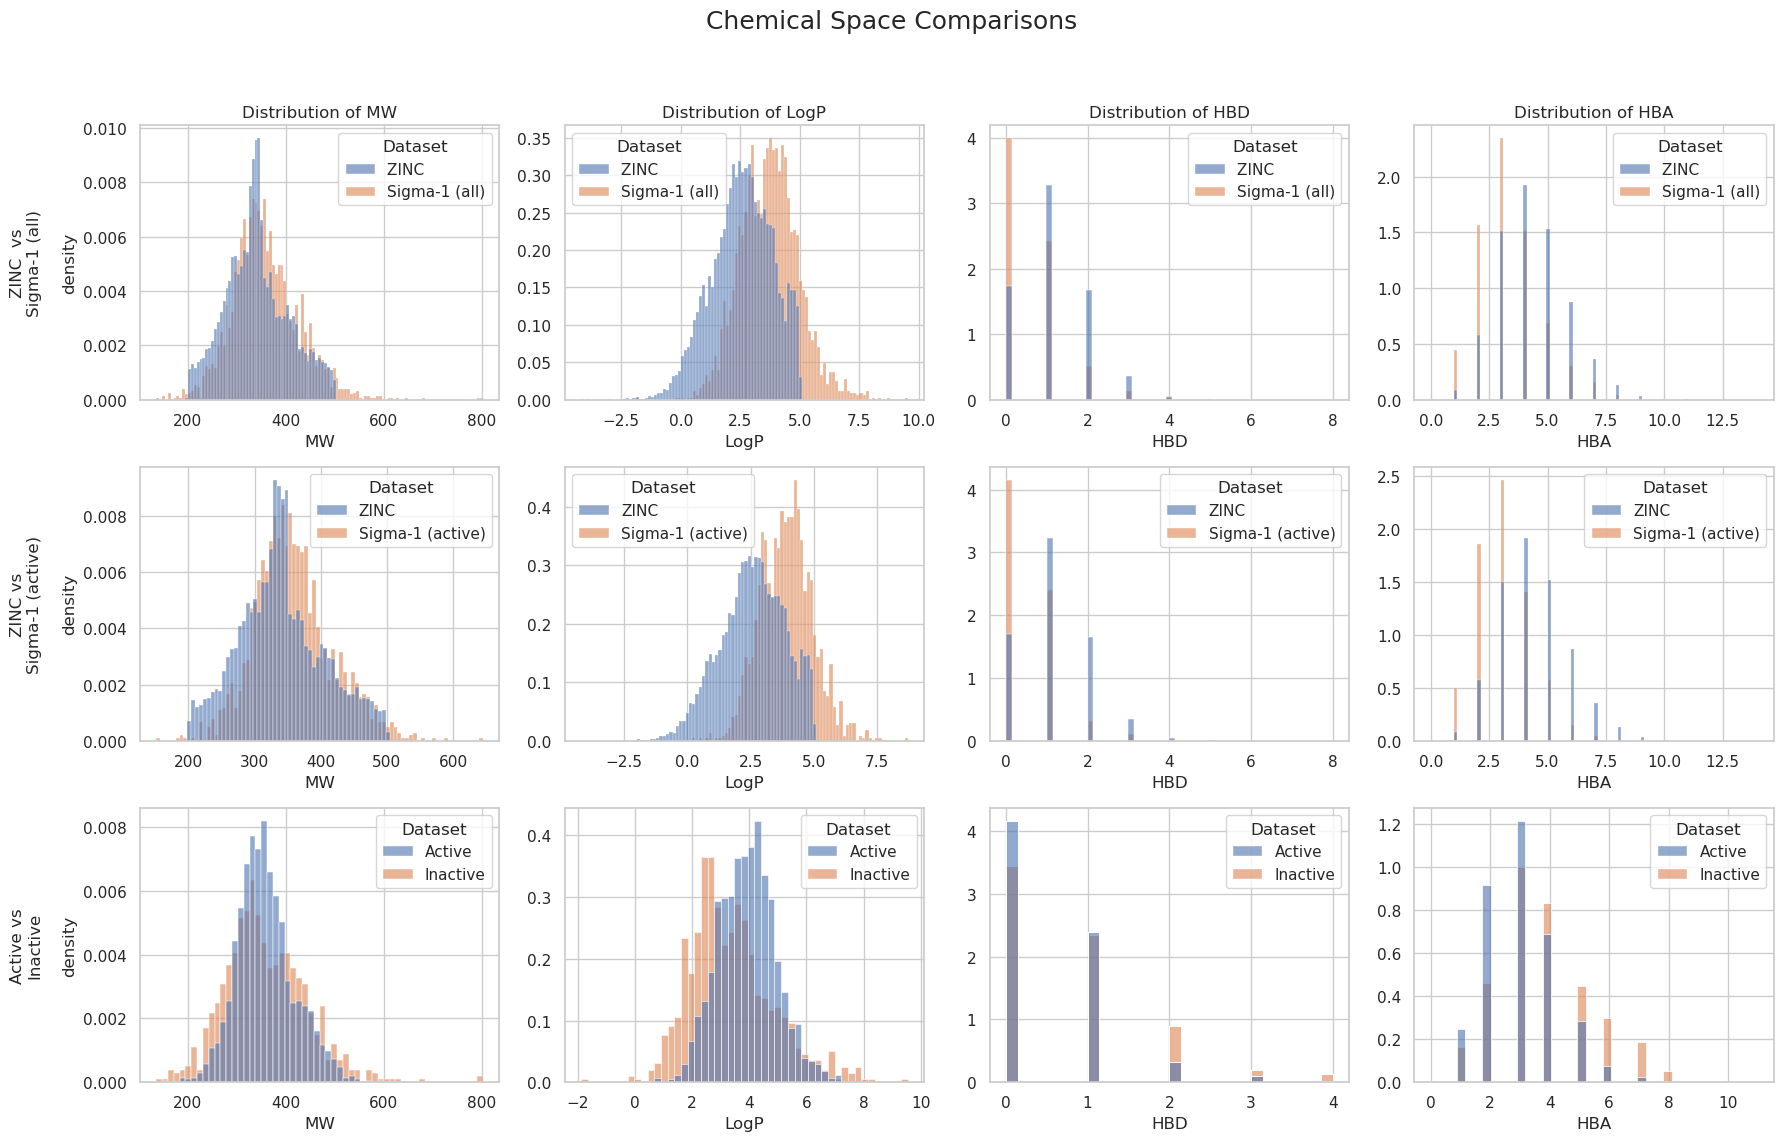

In [4]:
comparisons = [
    ([df_zinc, df_ki], ['ZINC ', 'Sigma-1 (all)']),
    ([df_zinc, df_active], ['ZINC', 'Sigma-1 (active)']),
    ([df_active, df_inactive], ['Active', 'Inactive'])
]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Chemical Space Comparisons', fontsize=18)

for row_idx, (data_list, labels) in enumerate(comparisons):
    
    combined_df = pd.concat([
        d[descriptors].assign(Dataset=label) for d, label in zip(data_list, labels)
    ], ignore_index=True)
    
    for col_idx, desc in enumerate(descriptors):
        ax = axes[row_idx, col_idx]
        
        sns.histplot(
            data=combined_df, 
            x=desc, 
            hue="Dataset", 
            ax=ax, 
            stat="density", 
            common_norm=False,
            kde=False,
            alpha=0.6
        )
        
        if row_idx == 0:
            ax.set_title(f'Distribution of {desc}')
        
        if col_idx == 0:
            ax.set_ylabel(f"{labels[0]} vs\n{labels[1]}\n\ndensity")
        else:
            ax.set_ylabel("")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

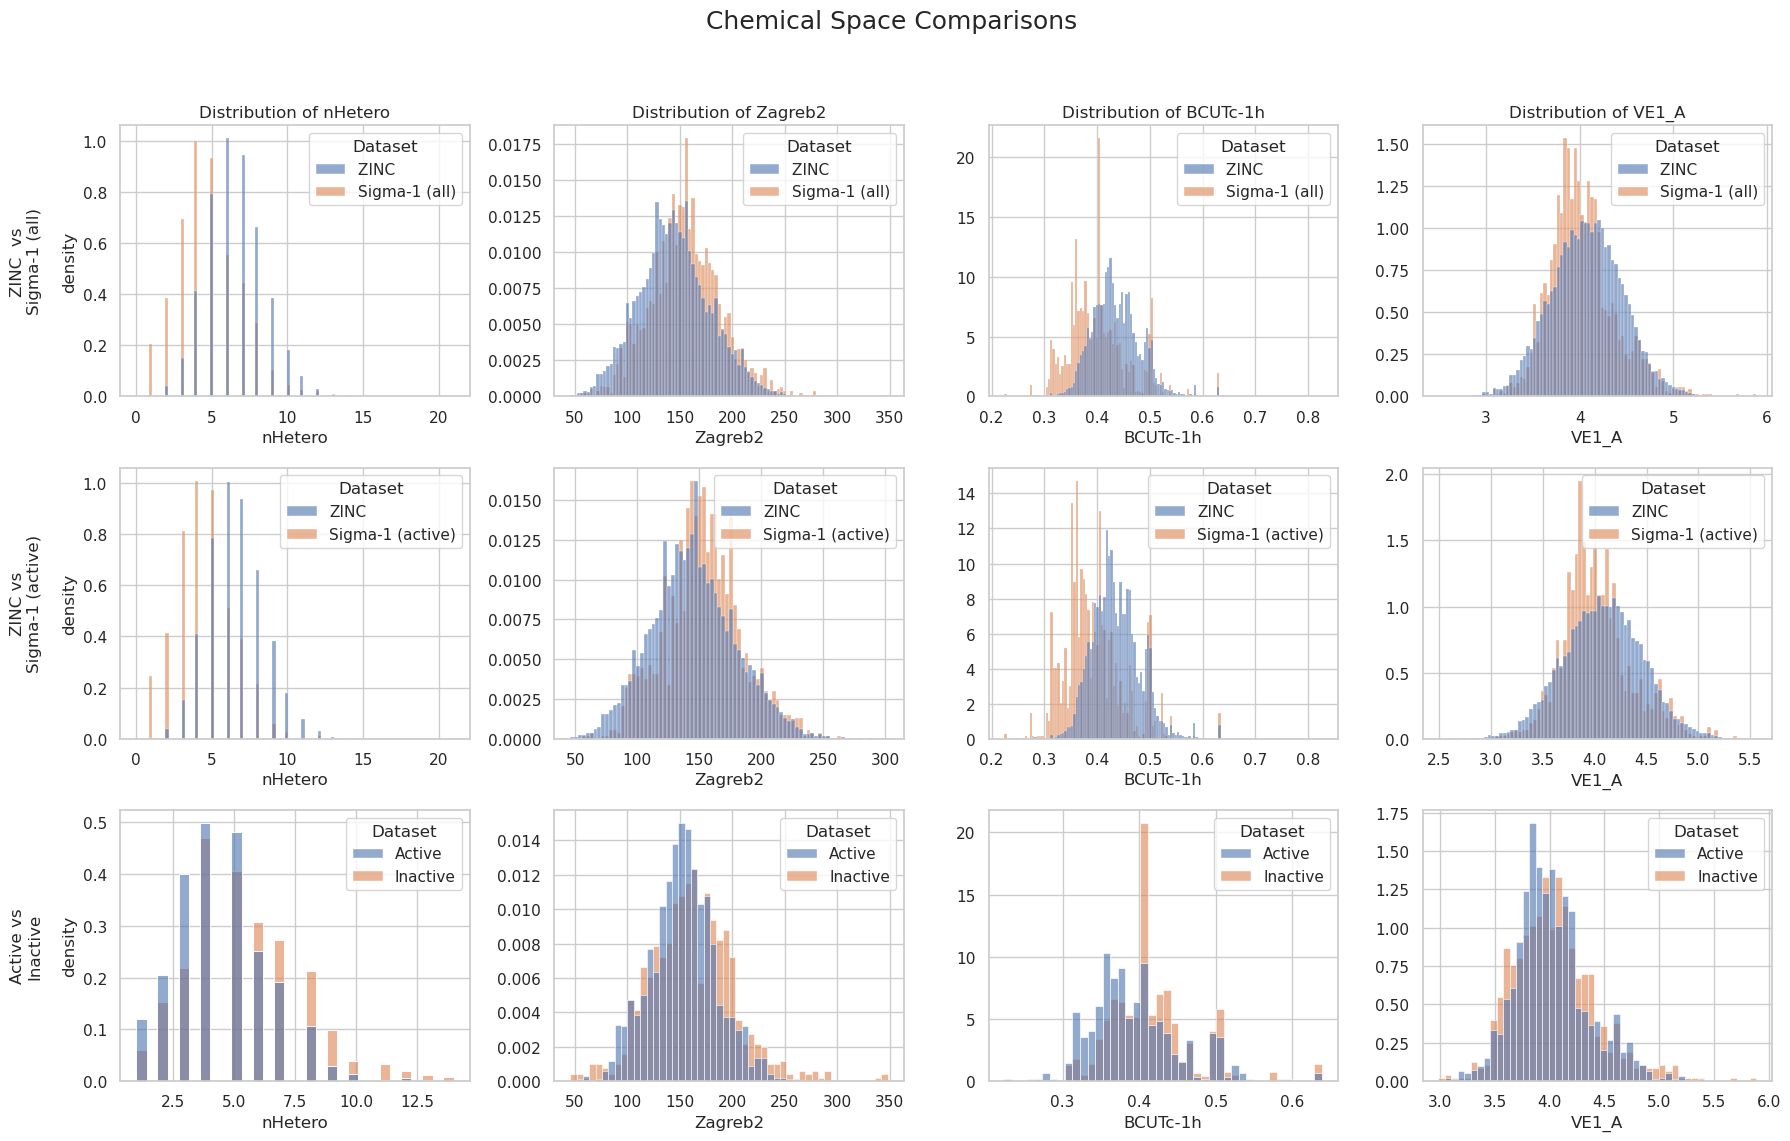

In [5]:
descriptors = ['nHetero', 'Zagreb2', 'BCUTc-1h', 'VE1_A']
comparisons = [
    ([df_zinc, df_ki], ['ZINC ', 'Sigma-1 (all)']),
    ([df_zinc, df_active], ['ZINC', 'Sigma-1 (active)']),
    ([df_active, df_inactive], ['Active', 'Inactive'])
]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Chemical Space Comparisons', fontsize=18)

for row_idx, (data_list, labels) in enumerate(comparisons):
    
    combined_df = pd.concat([
        d[descriptors].assign(Dataset=label) for d, label in zip(data_list, labels)
    ], ignore_index=True)
    
    for col_idx, desc in enumerate(descriptors):
        ax = axes[row_idx, col_idx]
        
        sns.histplot(
            data=combined_df, 
            x=desc, 
            hue="Dataset", 
            ax=ax, 
            stat="density", 
            common_norm=False,
            kde=False,
            alpha=0.6
        )
        
        if row_idx == 0:
            ax.set_title(f'Distribution of {desc}')
        
        if col_idx == 0:
            ax.set_ylabel(f"{labels[0]} vs\n{labels[1]}\n\ndensity")
        else:
            ax.set_ylabel("")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## UMAP

In [7]:
df_zinc = df_zinc.copy()
df_active = df_active.copy()
df_inactive = df_inactive.copy()

In [18]:
df_zinc['Dataset'] = 'ZINC'
df_active['Dataset'] = 'Active'
df_inactive['Dataset'] = 'Inactive'

In [20]:
common_cols = list(set(df_zinc.columns) & set(df_active.columns) & set(df_inactive.columns))
df_all = pd.concat([
    df_zinc[common_cols], 
    df_active[common_cols], 
    df_inactive[common_cols]
], ignore_index=True)

numeric_df = df_all.select_dtypes(include=[np.number])
clean_numeric_df = numeric_df.dropna(axis=1)

In [21]:
targets = [col for col in ['active', 'pK_i'] if col in clean_numeric_df.columns]
features = clean_numeric_df.drop(columns=targets)

In [30]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.8, random_state=42)
embedding = reducer.fit_transform(features)

/home/Baaa/miniconda3/envs/cheminf/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


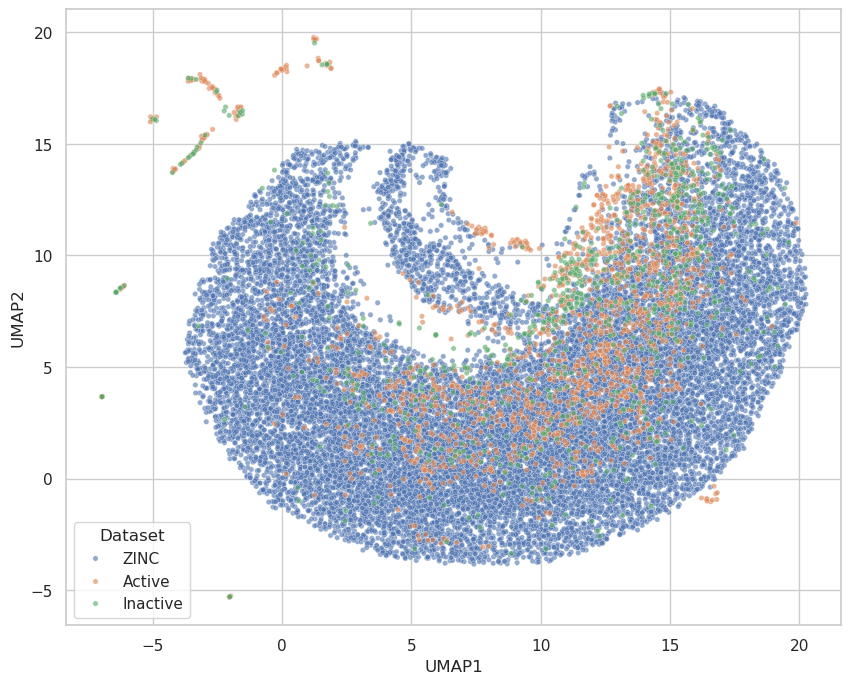

In [32]:
df_all['UMAP1'] = embedding[:, 0]
df_all['UMAP2'] = embedding[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_all, 
    x='UMAP1', 
    y='UMAP2', 
    hue='Dataset', 
    alpha=0.6, 
    s=15
)
plt.show()

## PCA

In [33]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

pca = PCA(n_components=2, random_state=42)
principal_components = pca.fit_transform(scaled_features)

df_all['PCA1'] = principal_components[:, 0]
df_all['PCA2'] = principal_components[:, 1]

explained_variance = pca.explained_variance_ratio_ * 100


/tmp/ipykernel_138970/1321556103.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_all['PCA1'] = principal_components[:, 0]
/tmp/ipykernel_138970/1321556103.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_all['PCA2'] = principal_components[:, 1]


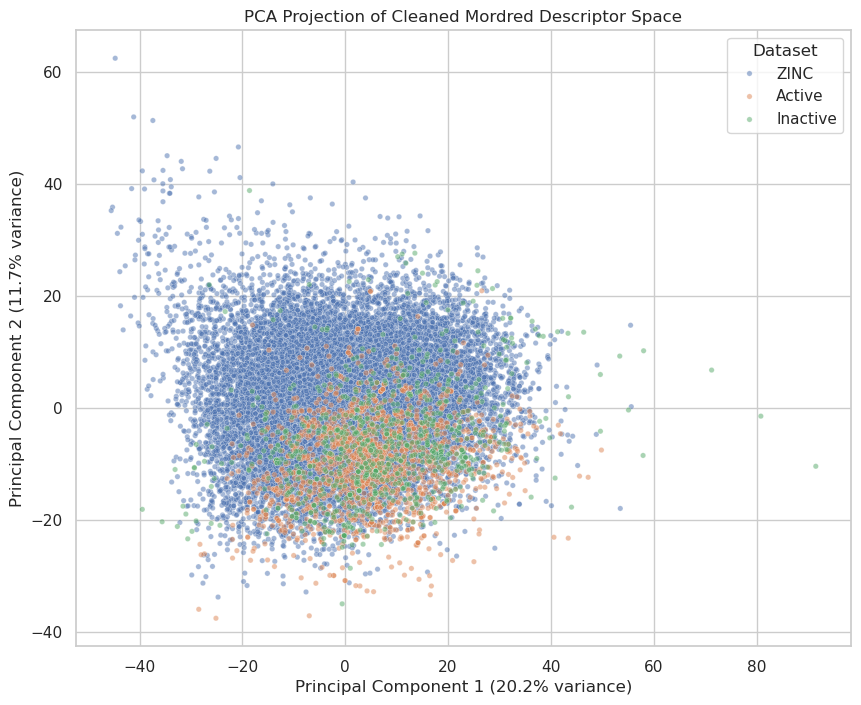

In [35]:

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_all, 
    x='PCA1', 
    y='PCA2', 
    hue='Dataset', 
    alpha=0.5, 
    s=15
)
plt.title('PCA Projection of Cleaned Mordred Descriptor Space')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.1f}% variance)')
plt.show()